# Multi-condition PEMFC comparison — QSS vs transient

Extends the analysis of `05_transient_vs_quasi_steady.ipynb` to all six MEA62 test
logs simultaneously, covering a range of operating conditions (temperature, pressure,
relative humidity) that tests `marapendi`'s physical coverage across a wide operating
envelope.

For each log, this notebook:
1. Loads and low-pass filters (0.1 Hz) the raw sensor signals.
2. Runs `ExplicitSteadyStateModel` in vectorised form (QSS) on the active window.
3. Integrates `TransientModel` over the same window with an adaptive-step ODE solver.
4. Collects all results in a `RESULTS` dict for cross-condition comparison plots.

The six conditions span 50–90 °C, 1.5–2.5 bar, and 30–80 % RH. A single `FuelCell`
instance is reused across all logs — the same physical MEA, different operating
conditions.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

import marapendi as mrpd
from marapendi.cell.transient import TransientModel
from marapendi.cell.explicit_steady_state import ExplicitSteadyStateModel

## 1 — Files and polarisation-curve windows

Edit `FILES` to set `t_start_h` / `t_end_h` for each log. Only samples with `I_Pile(A) > I_MIN` inside that window are used.

In [2]:
# (label, csv_path, t_start_h, t_end_h)
# Adjust t_start_h / t_end_h to bracket the polarisation-curve sweep in each file.
FILES = [
    ("02Mar", "data/experimental_data_MEA62_condition_A.csv", 1.63, 2.95),
    ("03Mar", "data/experimental_data_MEA62_condition_B.csv", 1.61, 2.85),
    ("05Mar", "data/experimental_data_MEA62_condition_C.csv", 1.62, 2.89),
    ("06Mar", "data/experimental_data_MEA62_condition_D.csv", 2.71, 3.95),
    ("09Mar", "data/experimental_data_MEA62_condition_E.csv", 1.50, 2.75),
    ("10Mar", "data/experimental_data_MEA62_condition_F.csv", 1.62, 2.90),
]

CELL_AREA = 25e-4   # m²
N_CELLS   = 1
I_MIN     = 0.5     # A — exclude near-zero-current samples
LPF_FC    = 0.1     # Hz — low-pass filter cutoff


def load_csv(path):
    df = pd.read_csv(path, sep=";", skiprows=6, encoding="latin1")
    df = df.rename(columns=lambda c: c.strip())
    old = list(df.columns)
    df = df.reset_index()
    df.columns = ["Time(s)"] + old[1:] + ["_extra"]
    df = df.drop(columns=["_extra"])
    df["Time(h)"] = (df["Time(s)"] - df["Time(s)"].iloc[0]) / 3600.0
    return df


# Quick sanity-check printout
for label, path, t0, t1 in FILES:
    df = load_csv(path)
    mask = (df["I_Pile(A)"] > I_MIN) & (df["Time(h)"] >= t0) & (df["Time(h)"] <= t1)
    sub = df[mask]
    print(
        f"{label}: [{t0:.2f}, {t1:.2f}] h  "
        f"n={mask.sum()}  I_max={sub['I_Pile(A)'].max():.1f} A  "
        f"T_stack={sub['T_pile(°C)'].median():.0f} °C  "
        f"p_ca={sub['P_Air_Out(bara)'].median():.2f} bar  "
        f"RH_ca={sub['RH_Air_calc(%)'].median():.0f} %"
    )

02Mar: [1.63, 2.95] h  n=4575  I_max=44.8 A  T_stack=80 °C  p_ca=2.30 bar  RH_ca=30 %
03Mar: [1.61, 2.85] h  n=4360  I_max=39.4 A  T_stack=70 °C  p_ca=1.50 bar  RH_ca=80 %
05Mar: [1.62, 2.89] h  n=4342  I_max=39.0 A  T_stack=80 °C  p_ca=1.50 bar  RH_ca=30 %
06Mar: [2.71, 3.95] h  n=4342  I_max=39.0 A  T_stack=80 °C  p_ca=1.50 bar  RH_ca=80 %
09Mar: [1.50, 2.75] h  n=4371  I_max=39.7 A  T_stack=40 °C  p_ca=2.50 bar  RH_ca=66 %
10Mar: [1.62, 2.90] h  n=4345  I_max=39.1 A  T_stack=80 °C  p_ca=1.50 bar  RH_ca=50 %


## 2 — Overview: current profiles with selected windows

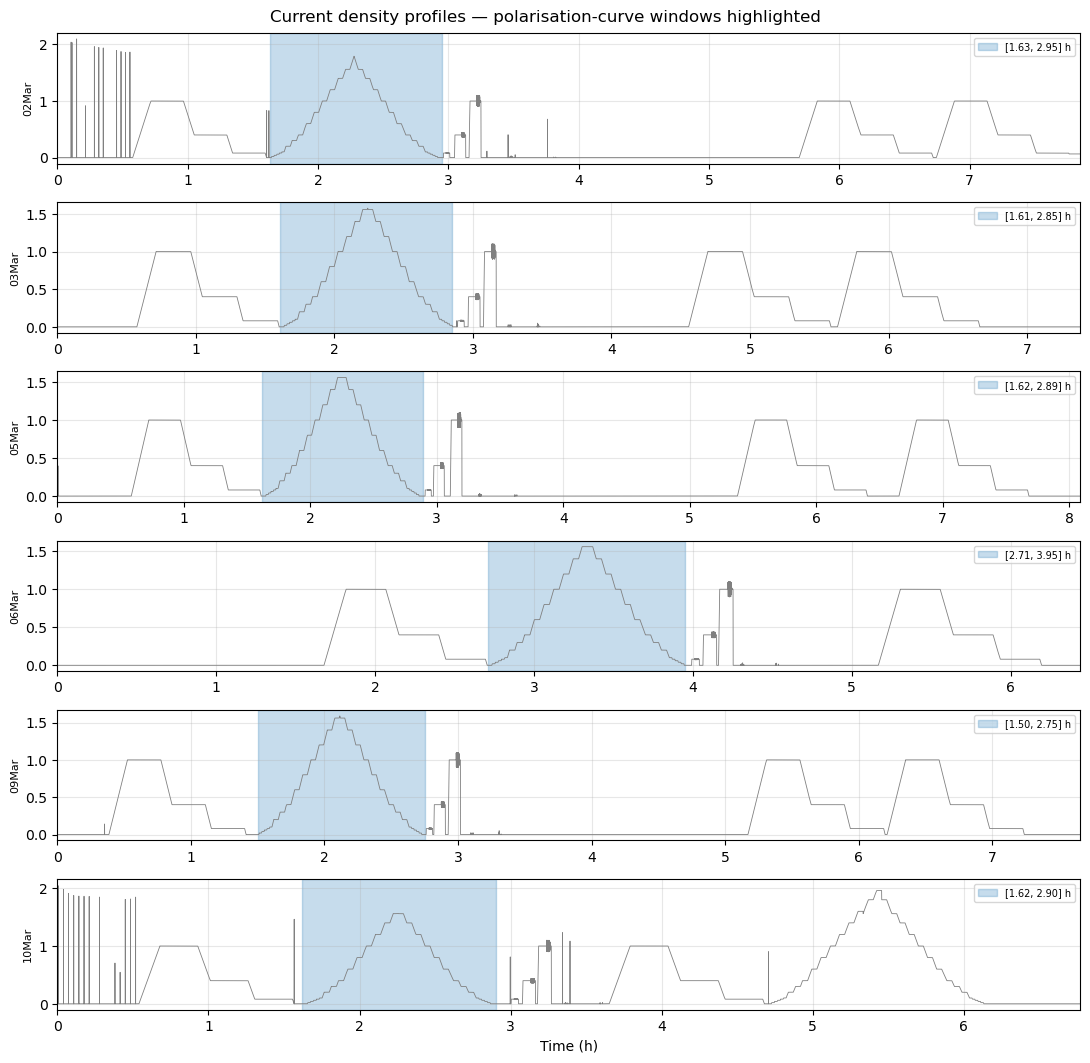

In [3]:
fig, axes = plt.subplots(len(FILES), 1, figsize=(11, 1.8 * len(FILES)), sharex=False)

for ax, (label, path, t0, t1) in zip(axes, FILES):
    df = load_csv(path)
    t  = df["Time(h)"].to_numpy()
    I  = df["I_Pile(A)"].to_numpy() / CELL_AREA * 1e-4   # A/cm²
    ax.plot(t, I, lw=0.6, color="0.5")
    ax.axvspan(t0, t1, alpha=0.25, color="C0", label=f"[{t0:.2f}, {t1:.2f}] h")
    ax.set_ylabel(label, fontsize=8)
    ax.legend(fontsize=7, loc="upper right")
    ax.set_xlim(t[0], t[-1])
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (h)")
fig.suptitle("Current density profiles — polarisation-curve windows highlighted")
fig.tight_layout()
plt.show()

## 3 — Cell parameters

MEA62 18-parameter estimation result from `08_parameter_estimation.ipynb`
(n = 18, left-out test case: condition 1). A single `FuelCell` instance is
assembled here and reused unchanged for all six log files — only the operating
conditions (`CellConditions`) change between files.

In [4]:
# Parameters not estimated for n=18 (held at initial guess / structural defaults).
fixed_parameters = {
    # structural
    "ionomer-k1": 8.5,
    "ionomer-k2": 5.4,
    "ionomer-k3": 5.4,
    "gdl-porosity": 0.6,
    "pt-wt-percent": 0.4,
    "ch-height": 1e-3,
    "cl-thermal-cond": 0.22,
    # not estimated in n=18 run (held at initial-guess values)
    "radius-carbon":    25e-9,
    "n_s":              2.0,
    "gdl-thickness":    150e-6,
    "gdl-theta":        120.,
    "cl-abs-perm":      1e-13,
    "wet-transition":   0.4,
    "pt-loading":       0.3e-2,
    "ic-ratio":         1.4,
    "ecsa":             60e3,
    "memb-water-diff":  2e-10,
    "E-act-memb-diff":  20e6,
    "E-act-memb-abs":   20e6,
    "cl-theta":         97.,
    "cl-pore-diameter": 40e-9,
    "memb-abs-constant": 1e-5,
    "ionomer-E-act-cond": 15e6,
    "gdl-abs-perm":     1e-12,
}

# n_parameters = 18, fold_id = 2 from k_fold_results_test.csv
estimated_parameters = {
    "elec-resistance":    3.467066875230129e-06,
    "alpha-c":            0.7281026506034132,
    "memb-cond-correction": 6.603921200288415,
    "B_ch":               1.5707938930296386,
    "ionomer-cond-corr":  1.0014324710948628,
    "i0-c":               0.0052142466891489,
    "E-act-ca":           58021540.64049202,
    "Sh":                 5.092865788506584,
    "gdl-thermal-cond":   0.0537423180937266,
    "memb-cond-exp":      1.3016511335718035,
    "memb-E-act-cond":    10196649.668377291,
    "memb-equiv-weight":  736.8899983350187,
    "gamma-c":            0.5772515728460474,
    "ix-corr":            1.999992272560833,
    "ionomer-cond-exp":   1.0537000908617322,
    "gdl-eff-diff-ratio": 0.1128415726042086,
    "memb-thickness":     9.65515328126366e-06,
    "tcr":                0.0006373882878159,
}

params = {**fixed_parameters, **estimated_parameters}


def create_cell(params):
    membrane = mrpd.PFSA(
        ionomer=mrpd.PFSAIonomer(
            equivalent_weight=params["memb-equiv-weight"], dry_density=2000.,
            conductivity_exp=params["memb-cond-exp"],
            conductivity_activation_energy=params["memb-E-act-cond"],
            conductivity_correction=params["memb-cond-correction"],
            reference_water_diffusivity=params["memb-water-diff"],
            reference_water_absorption_coefficient=params["memb-abs-constant"],
            water_diffusivity_activation_energy=params["E-act-memb-diff"],
            water_absorption_activation_energy=params["E-act-memb-abs"],
        ),
        dry_thickness=params["memb-thickness"],
    )
    orr = mrpd.ElectrochemicalReaction(
        reference_exchange_current_density=params["i0-c"],
        reaction_order=params["gamma-c"], activation_energy=params["E-act-ca"],
        reference_activity=1.01325e5, reference_temperature=353.15,
        number_of_electrons=1, charge_transfer_coeff=params["alpha-c"],
    )
    liq = mrpd.DarcyTransportModel(J_function_exponent=params["wet-transition"])
    gdl = {s: mrpd.GasDiffusionLayer(
        thickness=params["gdl-thickness"], contact_angle=params["gdl-theta"],
        effective_gas_diffusion_ratio=params["gdl-eff-diff-ratio"],
        absolute_permeability=params["gdl-abs-perm"], porosity=params["gdl-porosity"],
        thermal_conductivity=params["gdl-thermal-cond"], two_phase_transport_model=liq,
        transport_resistance_model=mrpd.PorousGasDiffusionModel(
            water_saturation_exponent=params["n_s"]),
    ) for s in ["ca", "an"]}
    ch = {s: mrpd.FlowChannel(
        height=params["ch-height"], width=1e-3, n_parallel=1, length=21 * 50e-3,
        reactant="o2" if s == "ca" else "h2",
        transport_resistance_model=mrpd.ChannelGasResistanceModel(
            sherwood=params["Sh"], B_ch=params["B_ch"]),
    ) for s in ["an", "ca"]}
    ion = mrpd.PFSAIonomer(
        conductivity_correction=params["ionomer-cond-corr"],
        conductivity_exp=params["ionomer-cond-exp"],
        conductivity_activation_energy=params["ionomer-E-act-cond"],
    )
    ca_cl = mrpd.PtCCatalystLayer(
        ecsa=params["ecsa"], platinum_loading=params["pt-loading"], ionomer=ion,
        catalyst_platinum_weight_percent=params["pt-wt-percent"],
        ionomer_to_carbon_ratio=params["ic-ratio"],
        ionomer_k1=params["ionomer-k1"], ionomer_k2=params["ionomer-k2"],
        ionomer_k3=params["ionomer-k3"],
        pore_diameter=params["cl-pore-diameter"], omega_PtO=0,
        carbon_agglomerate_radius=params["radius-carbon"],
        thickness=params["pt-loading"] * 2.8e-6 / 0.1e-2,
        absolute_permeability=params["cl-abs-perm"], contact_angle=params["cl-theta"],
        thermal_conductivity=params["cl-thermal-cond"], reaction=orr,
        two_phase_transport_model=liq,
        transport_resistance_model=mrpd.PorousGasDiffusionModel(water_saturation_exponent=1.5),
    )
    an_cl = mrpd.PtCCatalystLayer(
        ecsa=params["ecsa"], platinum_loading=1e-3,
        catalyst_platinum_weight_percent=params["pt-wt-percent"],
        ionomer_to_carbon_ratio=params["ic-ratio"], ionomer=ion,
        pore_diameter=params["cl-pore-diameter"],
        carbon_agglomerate_radius=params["radius-carbon"],
        thickness=2.8e-6, absolute_permeability=params["cl-abs-perm"],
        contact_angle=params["cl-theta"], thermal_conductivity=params["cl-thermal-cond"],
        two_phase_transport_model=liq,
        transport_resistance_model=mrpd.PorousGasDiffusionModel(water_saturation_exponent=1.5),
    )
    return mrpd.FuelCell(
        electric_resistance=params["elec-resistance"], area=CELL_AREA,
        ca=mrpd.FuelCellSide(cl=ca_cl, gdl=gdl["ca"],
                              ch=ch["ca"], thermal_contact_resistance=params["tcr"]),
        an=mrpd.FuelCellSide(cl=an_cl, gdl=gdl["an"],
                              ch=ch["an"], thermal_contact_resistance=params["tcr"]),
        membrane=membrane,
    )


cell = create_cell(params)
print("Cell assembled.")

Cell assembled.


## 4 — LPF, QSS and transient simulation

For each file: low-pass filter at 0.1 Hz, then run the vectorised quasi-steady model and the transient ODE. All results are stored in `RESULTS`.

In [ ]:
RESULTS = {}   # label → dict of arrays and timing

for label, path, T_START_H, T_END_H in FILES:
    print(f"\n{'─'*50}")
    print(f"  {label}  [{T_START_H:.2f}, {T_END_H:.2f}] h")

    df = load_csv(path)

    active = (
        (df["I_Pile(A)"] > I_MIN)
        & (df["Time(h)"] >= T_START_H)
        & (df["Time(h)"] <= T_END_H)
    ).to_numpy()

    df_a    = df[active].copy().reset_index(drop=True)
    t_abs_s = (df_a["Time(h)"] * 3600).to_numpy()
    t_rel_s = t_abs_s - t_abs_s[0]

    # ── LPF ──────────────────────────────────────────────────────────────
    dt_s = float(np.median(np.diff(t_rel_s)))
    b, a_filt = butter(4, LPF_FC / (1.0 / dt_s / 2), btype="low")

    def lpf(x, b=b, a=a_filt):
        return filtfilt(b, a, x)

    _I    = np.maximum(lpf(df_a["I_Pile(A)"].to_numpy()), I_MIN)
    _T_ca = lpf((df_a["T_Air_in(°C)"]   + 273.15).to_numpy())
    _p_ca = lpf((df_a["P_Air_Out(bara)"] * 1e5).to_numpy())
    _xi_ca = np.maximum(lpf(df_a["Stoeckio_air_calc"].to_numpy()), 1.01)
    
    _T_an  = lpf((df_a["T_H2_In(°C)"]   + 273.15).to_numpy())
    _p_an  = lpf((df_a["P_h2_out(bara)"] * 1e5).to_numpy())
    _xi_an = np.maximum(lpf(df_a["Stoeckio_h2_calc"].to_numpy()), 1.01)
    
    _T_c   = lpf((df_a["T_pile(°C)"]    + 273.15).to_numpy())
    _rh_ca = np.clip(lpf((df_a["RH_Air_calc(%)"] / 100.).to_numpy()), 0., 1.) 
    _rh_an = np.clip(lpf((df_a["RH_h2_calc(%)"] / 100.).to_numpy()), 0., 1.) 

    n_samp = len(_I)
    print(f"  {n_samp} active samples  ({t_rel_s[-1]:.0f} s)")

    # ── QSS (vectorised) ─────────────────────────────────────────────────
    ss_model = ExplicitSteadyStateModel()
    cond_v = mrpd.CellConditions(
        current_density=_I / CELL_AREA,
        cell_temperature=_T_c,
        ca=mrpd.SideConditions(
            inlet_temperature=_T_ca, outlet_pressure=_p_ca,
            dry_o2_mole_fraction=0.21,
            stoichiometry=_xi_ca, inlet_relative_humidity=_rh_ca,
        ),
        an=mrpd.SideConditions(
            inlet_temperature=_T_an, outlet_pressure=_p_an,
            dry_h2_mole_fraction=1.0,
            stoichiometry=_xi_an, inlet_relative_humidity=_rh_an,
        ),
    )
    t0_qss  = time.perf_counter()
    state_v = ss_model.set_initial_conditions(cell, cond_v)
    state_v = ss_model.solve(cell, cond_v, state_v)
    t_qss   = time.perf_counter() - t0_qss

    qss = {
        "cell_voltage":            np.atleast_1d(state_v.cell_voltage),
        "T_mea":                   np.atleast_1d(state_v.mea_temperature),
        "membrane_water_content":  np.atleast_1d(state_v.membrane.water_content),
        "ca_cl_water_content":     np.atleast_1d(state_v.ca.cl.ionomer_water_content),
        "an_cl_water_content":     np.atleast_1d(state_v.an.cl.ionomer_water_content),
        "ca_cl_liquid_saturation": np.atleast_1d(state_v.ca.cl.liquid_saturation),
        "ca_cl_proton_resistance": np.atleast_1d(state_v.ca.cl.proton_resistance),
        "hfr":                     np.atleast_1d(
            ss_model.voltage_model.high_frequency_resistance(cell, state_v)),
        "ca_water_flux":           np.atleast_1d(state_v.ca.water_flux),
        "ca_liquid_flux":          np.atleast_1d(state_v.ca.liquid_flux),
        "ca_membrane_water_flux":  np.atleast_1d(state_v.ca.membrane_water_flux),
        "ca_max_vapor_removal_flux": np.atleast_1d(state_v.ca.max_vapor_removal_flux),
    }
    print(f"  QSS: {t_qss*1e3:.0f} ms")

    # ── Transient ─────────────────────────────────────────────────────────
    # Capture loop variables explicitly to avoid closure issues
    def make_cond_fn(_t, _I, _T_c, _T_ca, _p_ca, _xi_ca, _rh_ca,
                     _T_an, _p_an, _xi_an, _rh_an):
        def cond_fn(t):
            t = np.clip(float(t), _t[0], _t[-1])
            return mrpd.CellConditions(
                current_density=np.atleast_1d(np.interp(t, _t, _I) / CELL_AREA),
                cell_temperature=float(np.interp(t, _t, _T_c)),
                ca=mrpd.SideConditions(
                    inlet_temperature=float(np.interp(t, _t, _T_ca)),
                    outlet_pressure=float(np.interp(t, _t, _p_ca)),
                    dry_o2_mole_fraction=0.21,
                    stoichiometry=float(np.interp(t, _t, _xi_ca)),
                    inlet_relative_humidity=float(np.interp(t, _t, _rh_ca)),
                ),
                an=mrpd.SideConditions(
                    inlet_temperature=float(np.interp(t, _t, _T_an)),
                    outlet_pressure=float(np.interp(t, _t, _p_an)),
                    dry_h2_mole_fraction=1.0,
                    stoichiometry=float(np.interp(t, _t, _xi_an)),
                    inlet_relative_humidity=float(np.interp(t, _t, _rh_an)),
                ),
            )
        return cond_fn

    cond_fn = make_cond_fn(
        t_rel_s, _I, _T_c, _T_ca, _p_ca, _xi_ca, _rh_ca,
        _T_an, _p_an, _xi_an, _rh_an,
    )

    tr_model = TransientModel(n_memb_mesh=5)
    _, x0 = tr_model.set_initial_conditions(cell, cond_fn(0.))

    t0_tr = time.perf_counter()
    sol = tr_model.solve(
        cell, cond_fn,
        t_span=(0., float(t_rel_s[-1])),
        x0=x0,
        dense_output=True,
        max_step=60.,
        compute_diagnostics=False,
    )
    t_tr_solve = time.perf_counter() - t0_tr

    t0_ev = time.perf_counter()
    tr = tr_model.evaluate(cell, cond_fn, t_rel_s, x_eval=sol.sol(t_rel_s))
    t_tr_post = time.perf_counter() - t0_ev
    t_tr_total = t_tr_solve + t_tr_post

    print(f"  Transient: ODE {t_tr_solve:.1f} s ({len(sol.t)} steps) + "
          f"eval {t_tr_post:.1f} s = {t_tr_total:.1f} s total")

    # ── Condition label (for plot titles) ─────────────────────────────────
    cond_label = (
        f"T={np.median(_T_c)-273.15:.0f} °C "
        r"p$_{ca/an}$="+f"{np.median(_p_ca)*1e-5:.1f}/{np.median(_p_an)*1e-5:.1f} bar \n"
        r"RH$_{ca/an}$="+f"{np.median(_rh_ca)*100:.0f}%/{np.median(_rh_an)*100:.0f}% "
        r"$\lambda_{ca/an}$="+f"{np.median(_xi_ca):.1f}/{np.median(_xi_an):.1f}"
    )

    RESULTS[label] = dict(
        t_h       = t_rel_s / 3600.,
        t_rel_s   = t_rel_s,
        meas_V    = df_a["U_Pile(V)"].to_numpy() / N_CELLS,
        meas_I    = _I / CELL_AREA * 1e-4,
        T_stack_C = df_a["T_pile(°C)"].to_numpy(),
        _T_ca=_T_ca, _T_an=_T_an, _T_c=_T_c,
        _p_ca=_p_ca, _p_an=_p_an,
        _rh_ca=_rh_ca, _rh_an=_rh_an,
        _xi_ca=_xi_ca, _xi_an=_xi_an, _I=_I,
        qss=qss, tr=tr,
        t_qss=t_qss, t_tr_solve=t_tr_solve,
        t_tr_post=t_tr_post, t_tr_total=t_tr_total,
        n_steps=len(sol.t), T_SIM=float(t_rel_s[-1]),
        cond_label=cond_label,
    )

print("\nDone.")


──────────────────────────────────────────────────
  02Mar  [1.63, 2.95] h
  4575 active samples  (4574 s)
  QSS: 7 ms


## 5 — Computational cost

In [ ]:
labels = list(RESULTS)
n = len(labels)
print(f"{'File':<8} {'QSS (ms)':>10} {'ODE (s)':>9} {'ODE steps':>10} "
      f"{'Eval (s)':>9} {'Total (s)':>10}")
print("─" * 62)
for lbl in labels:
    r = RESULTS[lbl]
    print(f"{lbl:<8} {r['t_qss']*1e3:>10.0f} {r['t_tr_solve']:>9.1f} "
          f"{r['n_steps']:>10d} {r['t_tr_post']:>9.1f} {r['t_tr_total']:>10.1f}") 

File       QSS (ms)   ODE (s)  ODE steps  Eval (s)  Total (s)
──────────────────────────────────────────────────────────────
02Mar             8       3.8        852       0.1        3.9
03Mar             6       3.3        743       0.1        3.4
05Mar             9       4.0        875       0.1        4.1
06Mar             7       3.2        708       0.1        3.3
09Mar             6       2.0        435       0.1        2.2
10Mar             6       4.2        937       0.1        4.4


In [ ]:
labels = list(RESULTS)
n = len(labels)
print(f"{'File':<8} {'QSS (xRT)':>10} {'ODE (xRT)':>10}")
print("─" * 62)
for lbl in labels:
    r = RESULTS[lbl]
    print(f"{lbl:<8} {(t_rel_s[-1]-t_rel_s[0])/r['t_qss']:>10.0f} {(t_rel_s[-1]-t_rel_s[0])/r['t_tr_total']:>10.1f}") 

File      QSS (xRT)  ODE (xRT)
──────────────────────────────────────────────────────────────
02Mar        529167     1114.4
03Mar        767220     1267.6
05Mar        494568     1060.4
06Mar        649210     1319.2
09Mar        754330     2019.8
10Mar        670526      995.7


## 6 — Comparison plots

Each column is one file. Time axis is relative to the start of the selected polarisation-curve window.

### 6.0 Operating conditions (low-pass filtered)

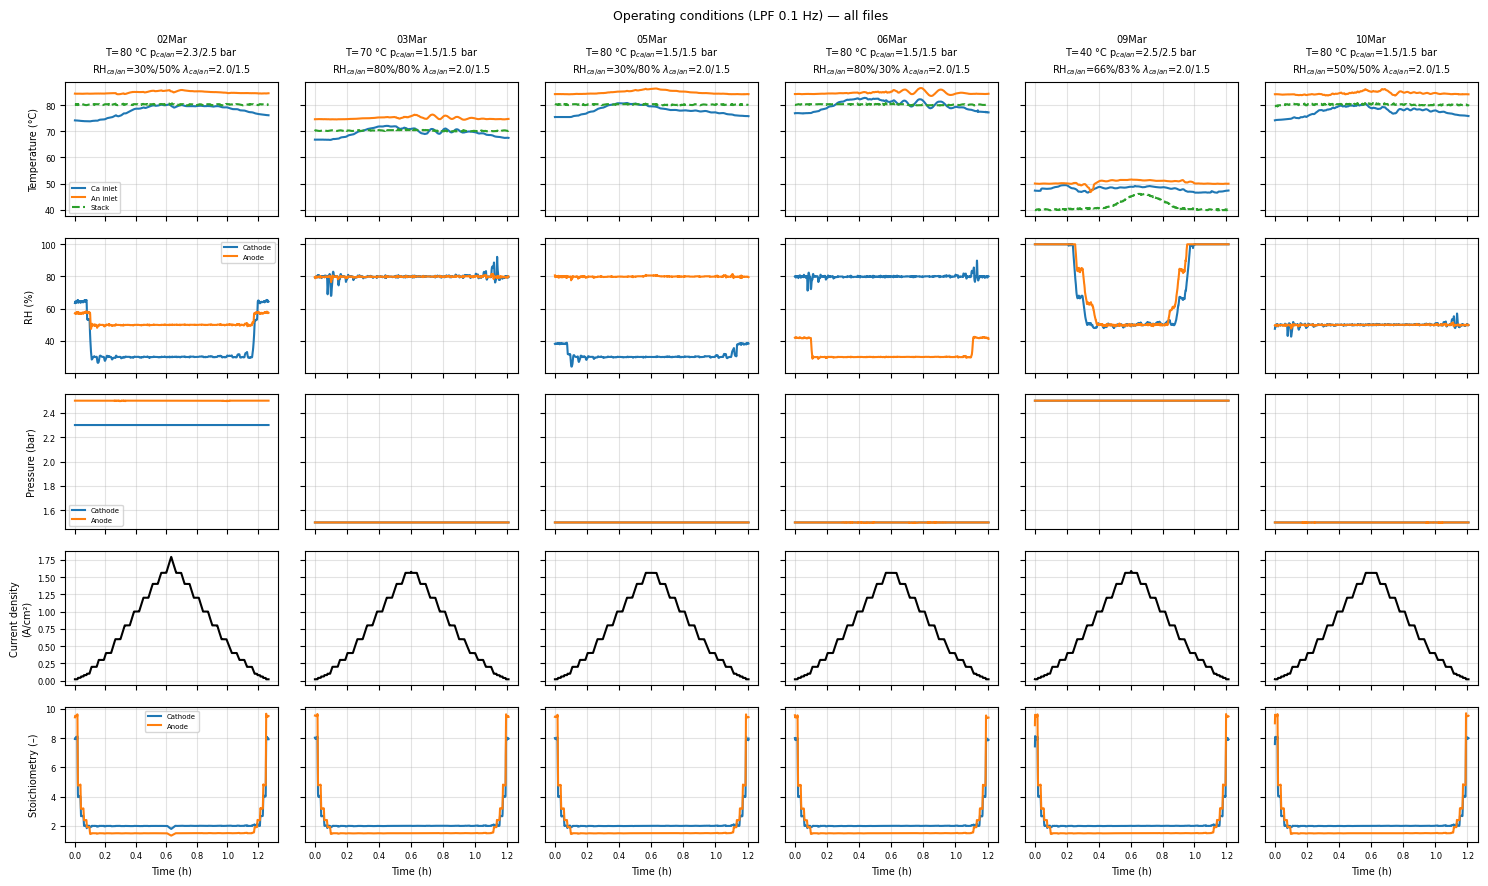

In [ ]:
labels = list(RESULTS)
n = len(labels)
fig, axes = plt.subplots(5, n, figsize=(2.5*n, 9), sharex="col", sharey='row')

for j, lbl in enumerate(labels):
    r = RESULTS[lbl]
    t = r["t_h"]

    axes[0, j].plot(t, r["_T_ca"] - 273.15, label="Ca inlet")
    axes[0, j].plot(t, r["_T_an"] - 273.15, label="An inlet")
    axes[0, j].plot(t, r["_T_c"]  - 273.15, label="Stack", ls="--")
    axes[0, j].set_title(f"{lbl}\n{r['cond_label']}", fontsize=7)

    axes[1, j].plot(t, r["_rh_ca"] * 100, label="Cathode")
    axes[1, j].plot(t, r["_rh_an"] * 100, label="Anode")

    axes[2, j].plot(t, r["_p_ca"] * 1e-5, label="Cathode")
    axes[2, j].plot(t, r["_p_an"] * 1e-5, label="Anode")

    axes[3, j].plot(t, r["meas_I"], color="k")

    axes[4, j].plot(t, r["_xi_ca"], label="Cathode")
    axes[4, j].plot(t, r["_xi_an"], label="Anode")
    axes[4, j].set_xlabel("Time (h)", fontsize=7)

ylabels = [
    "Temperature (°C)", "RH (%)",
    "Pressure (bar)", "Current density\n(A/cm²)", "Stoichiometry (–)"
]
for i, yl in enumerate(ylabels):
    axes[i, 0].set_ylabel(yl, fontsize=7)
    for j in range(n):
        axes[i, j].grid(True, alpha=0.35)
        axes[i, j].tick_params(labelsize=6)
        if i == 0 and j == 0:
            axes[i, j].legend(fontsize=5, loc="best")
        if i in (1, 2, 4) and j == 0:
            axes[i, j].legend(fontsize=5, loc="best")

fig.suptitle("Operating conditions (LPF 0.1 Hz) — all files", fontsize=9)
fig.tight_layout()
plt.show()

### 6.1 Cell voltage

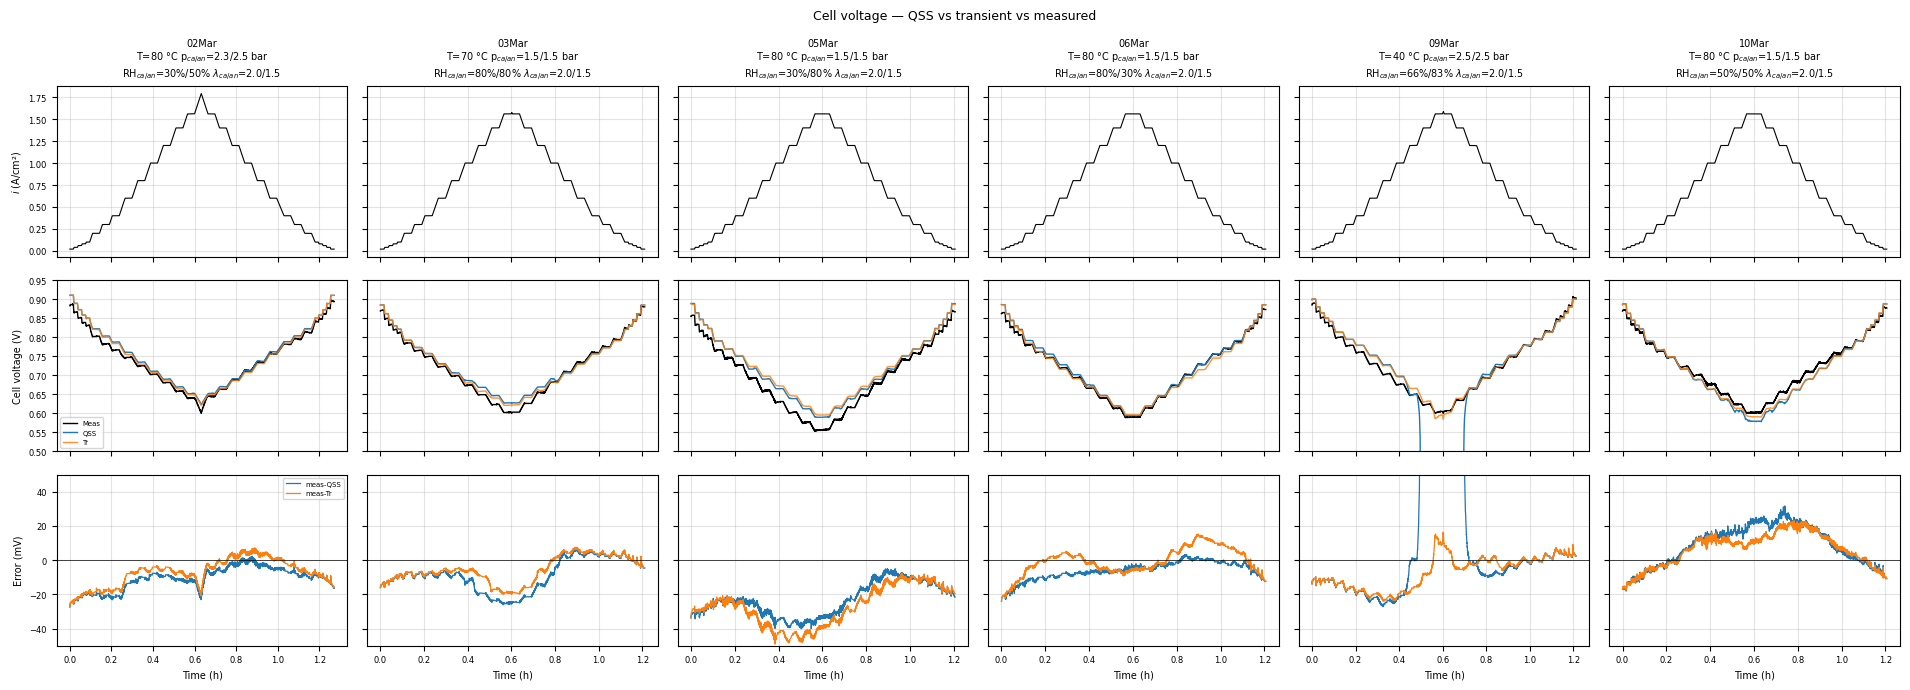

In [ ]:
labels = list(RESULTS)
n = len(labels)
fig, axes = plt.subplots(3, n, figsize=(3.2*n, 7), sharex="col", sharey='row')

for j, lbl in enumerate(labels):
    r = RESULTS[lbl]
    t = r["t_h"]
    tr = r["tr"]

    axes[0, j].plot(t, r["meas_I"], "k", lw=0.8)
    axes[0, j].set_title(f"{lbl}\n{r['cond_label']}", fontsize=7)

    axes[1, j].plot(t, r["meas_V"],               "k",  lw=1., label="Meas")
    axes[1, j].plot(t, r["qss"]["cell_voltage"],   "C0", lw=1., label="QSS")
    axes[1, j].plot(t, tr.cell_voltage,             "C1", lw=1., label="Tr", alpha=0.85)
    axes[1, j].set_ylim([0.5, 0.95])

    axes[2, j].plot(t, 1e3*(r["meas_V"] - r["qss"]["cell_voltage"]), "C0", lw=0.9,
                    label="meas-QSS")
    axes[2, j].plot(t, 1e3*(r["meas_V"] - tr.cell_voltage),           "C1", lw=0.9,
                    label="meas-Tr")
    axes[2, j].axhline(0, color="k", lw=0.5)
    axes[2, j].set_xlabel("Time (h)", fontsize=7)
    axes[2, j].set_ylim([-50, 50])

axes[0, 0].set_ylabel("$i$ (A/cm²)", fontsize=7)
axes[1, 0].set_ylabel("Cell voltage (V)", fontsize=7)
axes[2, 0].set_ylabel("Error (mV)", fontsize=7)
for i in range(3):
    for j in range(n):
        axes[i, j].grid(True, alpha=0.35)
        axes[i, j].tick_params(labelsize=6)
axes[1, 0].legend(fontsize=5)
axes[2, 0].legend(fontsize=5)

fig.suptitle("Cell voltage — QSS vs transient vs measured", fontsize=9)
fig.tight_layout()
plt.show()

### 6.2 MEA temperature

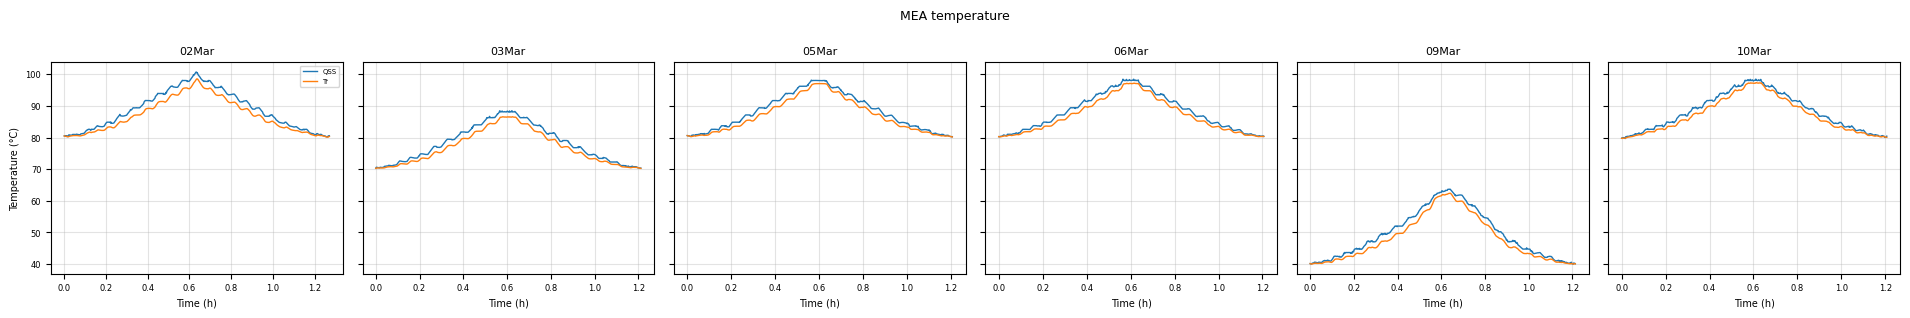

In [ ]:
labels = list(RESULTS)
n = len(labels)
fig, axes = plt.subplots(1, n, figsize=(3.2*n, 3.2), sharey=True)

for j, lbl in enumerate(labels):
    r = RESULTS[lbl]
    t = r["t_h"]
    tr = r["tr"]
    axes[j].plot(t, r["qss"]["T_mea"] - 273.15,  "C0", lw=1., label="QSS")
    axes[j].plot(t, tr.mea_temperature - 273.15,   "C1", lw=1., label="Tr")
    axes[j].set_title(lbl, fontsize=8)
    axes[j].set_xlabel("Time (h)", fontsize=7)
    axes[j].grid(True, alpha=0.35)
    axes[j].tick_params(labelsize=6)

axes[0].set_ylabel("Temperature (°C)", fontsize=7)
axes[0].legend(fontsize=5)
fig.suptitle("MEA temperature", fontsize=9)
fig.tight_layout()
plt.show()

### 6.3 Water contents

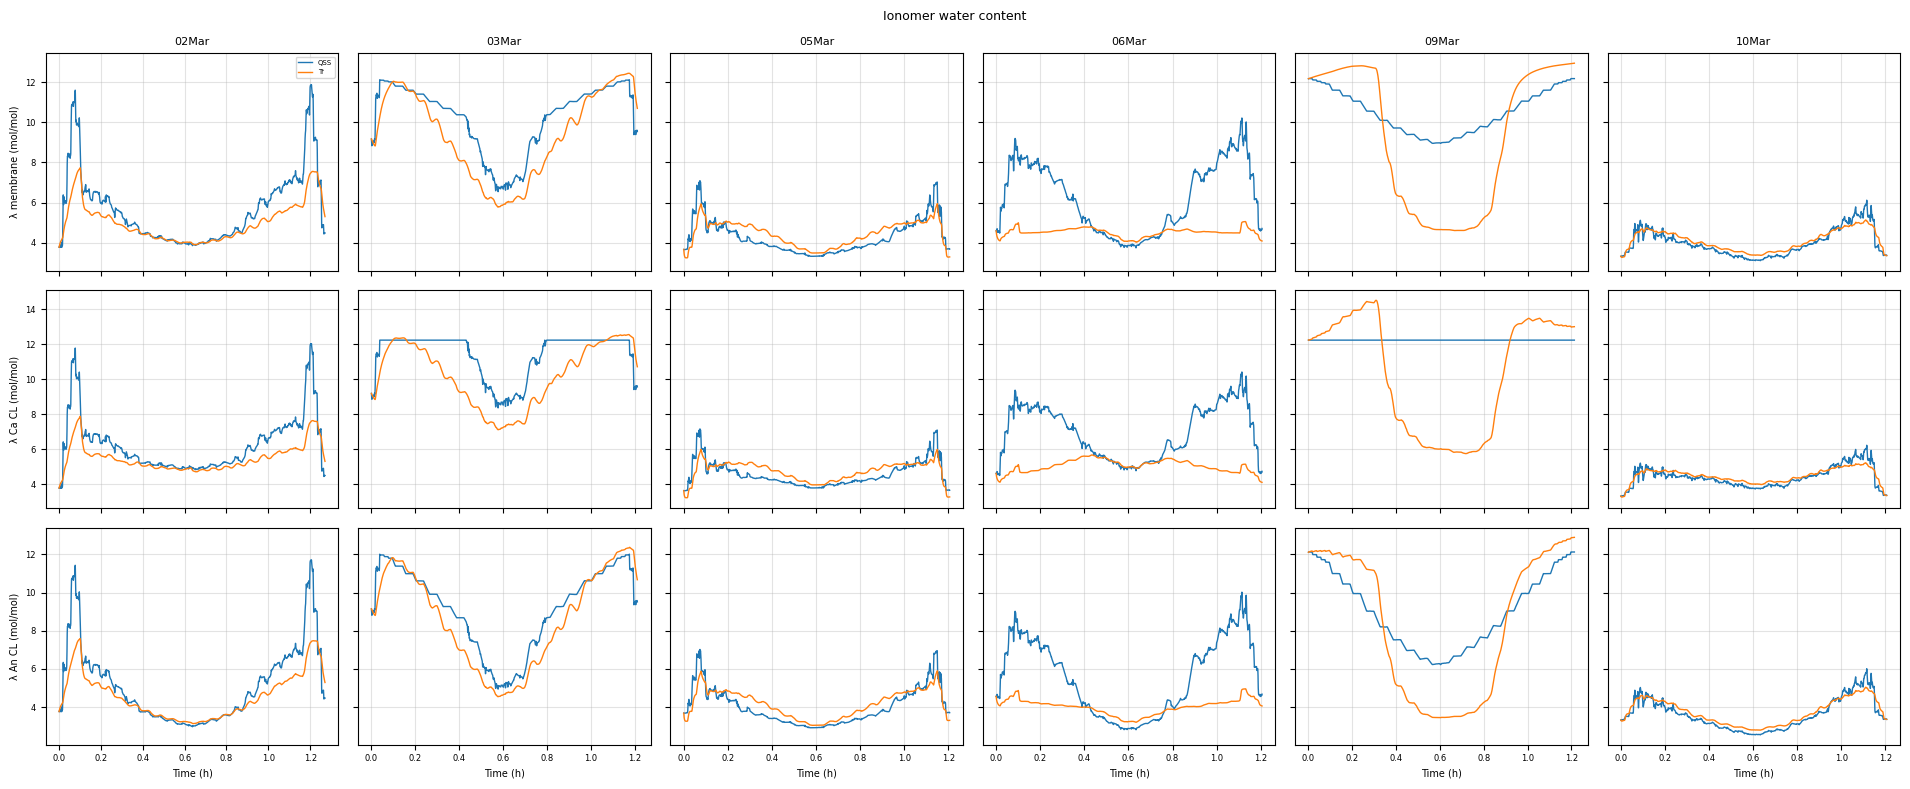

In [ ]:
labels = list(RESULTS)
n = len(labels)
fig, axes = plt.subplots(3, n, figsize=(3.2*n, 8), sharex="col", sharey='row')

rows = [
    ("membrane_water_content", "λ membrane",  lambda tr: tr.membrane.water_content),
    ("ca_cl_water_content",    "λ Ca CL",     lambda tr: tr.ca.cl.ionomer_water_content),
    ("an_cl_water_content",    "λ An CL",     lambda tr: tr.an.cl.ionomer_water_content),
]

for j, lbl in enumerate(labels):
    r = RESULTS[lbl]
    t = r["t_h"]
    tr = r["tr"]
    axes[0, j].set_title(lbl, fontsize=8)
    for i, (key, _, tr_fn) in enumerate(rows):
        axes[i, j].plot(t, r["qss"][key], "C0", lw=1., label="QSS")
        axes[i, j].plot(t, tr_fn(tr),      "C1", lw=1., label="Tr")
        axes[i, j].grid(True, alpha=0.35)
        axes[i, j].tick_params(labelsize=6)
    axes[2, j].set_xlabel("Time (h)", fontsize=7)

for i, (_, ylabel, _) in enumerate(rows):
    axes[i, 0].set_ylabel(ylabel + " (mol/mol)", fontsize=7)
axes[0, 0].legend(fontsize=5)

fig.suptitle("Ionomer water content", fontsize=9)
fig.tight_layout()
plt.show()

### 6.4 Cathode CL liquid saturation

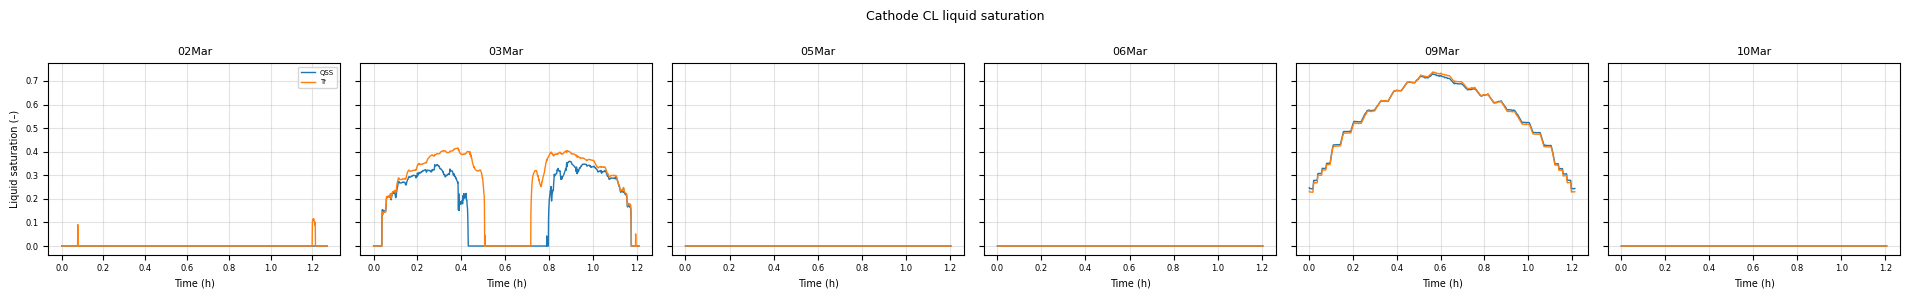

In [ ]:
labels = list(RESULTS)
n = len(labels)
fig, axes = plt.subplots(1, n, figsize=(3.2*n, 3.0), sharey=True)

for j, lbl in enumerate(labels):
    r = RESULTS[lbl]
    t = r["t_h"]
    tr = r["tr"]
    axes[j].plot(t, r["qss"]["ca_cl_liquid_saturation"], "C0", lw=1., label="QSS")
    axes[j].plot(t, tr.ca.cl.liquid_saturation,           "C1", lw=1., label="Tr")
    axes[j].set_title(lbl, fontsize=8)
    axes[j].set_xlabel("Time (h)", fontsize=7)
    axes[j].grid(True, alpha=0.35)
    axes[j].tick_params(labelsize=6)

axes[0].set_ylabel("Liquid saturation (–)", fontsize=7)
axes[0].legend(fontsize=5)
fig.suptitle("Cathode CL liquid saturation", fontsize=9)
fig.tight_layout()
plt.show()

### 6.5 HFR and cathode CL proton resistance

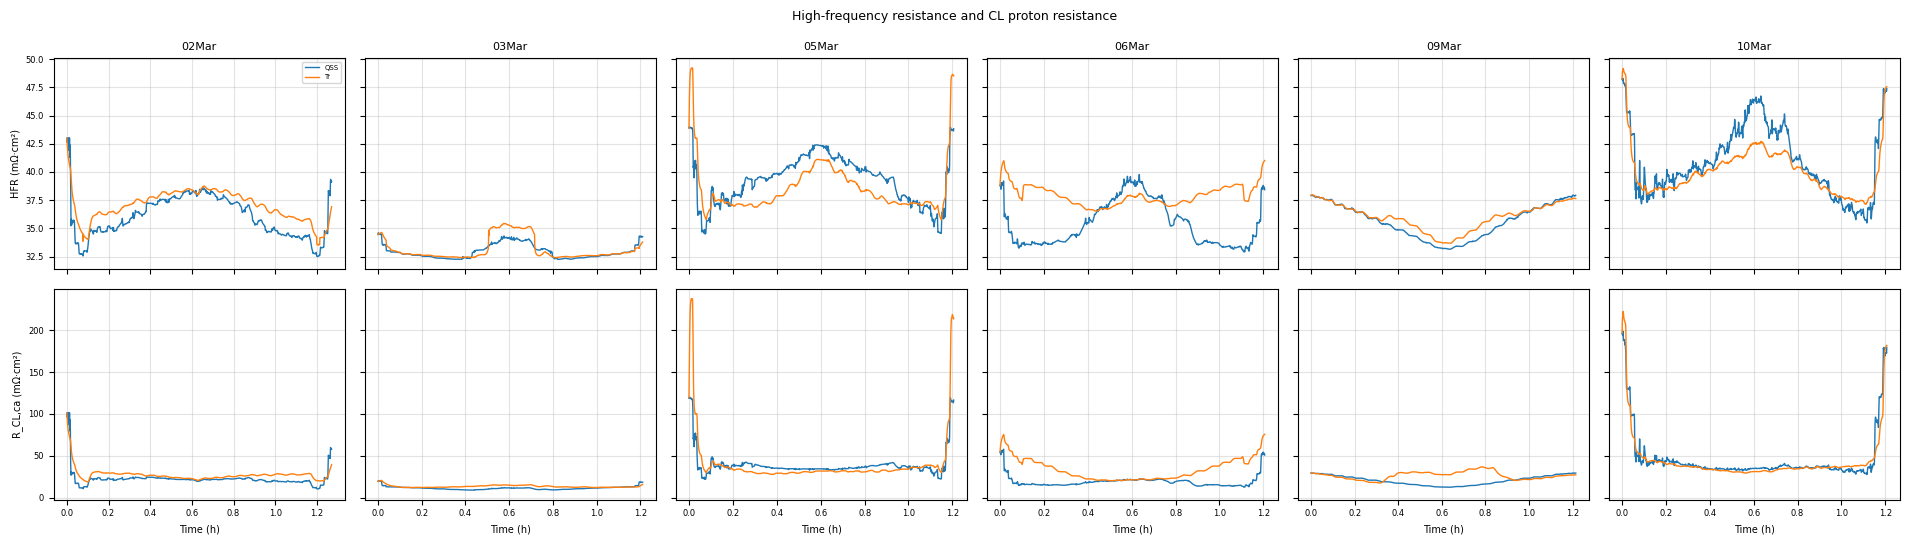

In [ ]:
labels = list(RESULTS)
n = len(labels)
fig, axes = plt.subplots(2, n, figsize=(3.2*n, 5.5), sharex="col", sharey='row')

for j, lbl in enumerate(labels):
    r = RESULTS[lbl]
    t = r["t_h"]
    tr = r["tr"]
    axes[0, j].plot(t, r["qss"]["hfr"] * 1e7,                  "C0", lw=1., label="QSS")
    axes[0, j].plot(t, tr.hfr * 1e7,                             "C1", lw=1., label="Tr")
    axes[1, j].plot(t, r["qss"]["ca_cl_proton_resistance"] * 1e7, "C0", lw=1.)
    axes[1, j].plot(t, tr.ca.cl.proton_resistance * 1e7,          "C1", lw=1.)
    axes[0, j].set_title(lbl, fontsize=8)
    axes[1, j].set_xlabel("Time (h)", fontsize=7)
    for i in range(2):
        axes[i, j].grid(True, alpha=0.35)
        axes[i, j].tick_params(labelsize=6)

axes[0, 0].set_ylabel("HFR (mΩ·cm²)", fontsize=7)
axes[1, 0].set_ylabel("R_CL,ca (mΩ·cm²)", fontsize=7)
axes[0, 0].legend(fontsize=5)

fig.suptitle("High-frequency resistance and CL proton resistance", fontsize=9)
fig.tight_layout()
plt.show()

### 6.6 Cathode water fluxes (QSS)

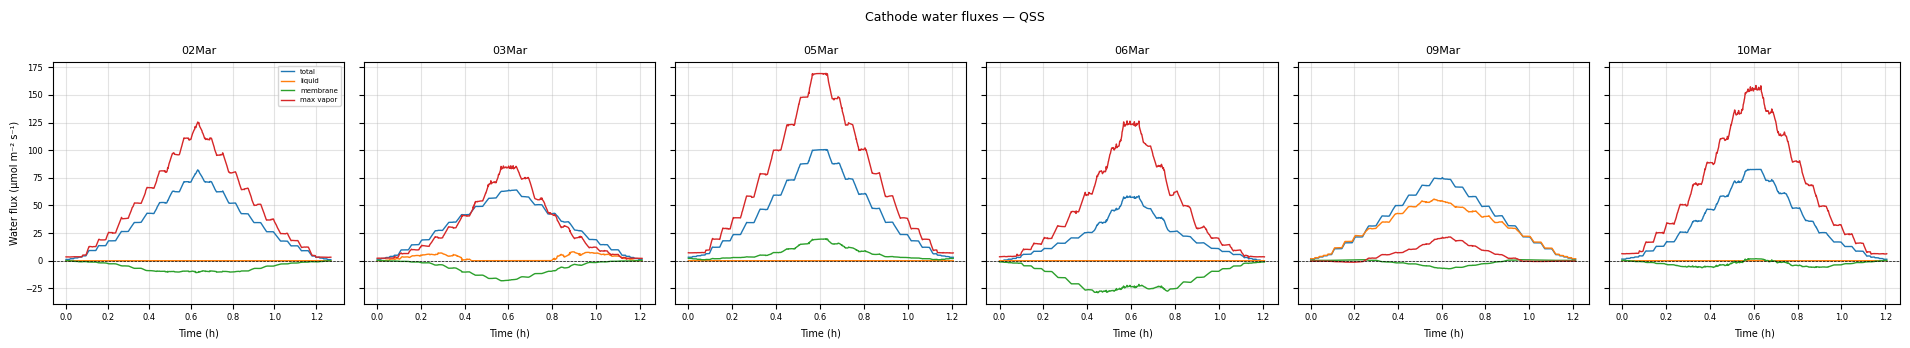

In [ ]:
labels = list(RESULTS)
n = len(labels)
fig, axes = plt.subplots(1, n, figsize=(3.2 * n, 3.5), sharey=True)

flux_keys = [
    ("ca_water_flux",             "total",     "C0"),
    ("ca_liquid_flux",            "liquid",    "C1"),
    ("ca_membrane_water_flux",    "membrane",  "C2"),
    ("ca_max_vapor_removal_flux", "max vapor", "C3"),
]

for j, lbl in enumerate(labels):
    r = RESULTS[lbl]
    t = r["t_h"]
    for key, name, color in flux_keys:
        axes[j].plot(t, r["qss"][key] * 1e6, color=color, lw=1., label=name)
    axes[j].axhline(0, color="k", lw=0.5, ls="--")
    axes[j].set_title(lbl, fontsize=8)
    axes[j].set_xlabel("Time (h)", fontsize=7)
    axes[j].grid(True, alpha=0.35)
    axes[j].tick_params(labelsize=6)

axes[0].set_ylabel("Water flux (µmol m⁻² s⁻¹)", fontsize=7)
axes[0].legend(fontsize=5, loc="best")

fig.suptitle("Cathode water fluxes — QSS", fontsize=9)
fig.tight_layout()
plt.show()